In [1]:
import os
import json
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset

from gap.classifiers import SmallCNN
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer

In [2]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models/CIFAR-10/SmallCNN_20Epoch_20260320_1419"

metadata_path = os.path.join(RUN_DIR, "metadata.json")
weights_path = os.path.join(RUN_DIR, "weights.pth")

with open(metadata_path, "r") as f:
    best_config = json.load(f)

print(f"Loaded config: {best_config}")

Using device: mps
Loaded config: {'lr': 0.0034828441557961947, 'channels': 64, 'depth': 2, 'opt': 'adam'}


In [3]:
# Instantiate the model using the weights and metadata loaded
trained_model = SmallCNN(
    num_classes=10, channels=best_config["channels"], depth=best_config["depth"]
).to(device)

trained_model.load_state_dict(
    torch.load(weights_path, map_location=device, weights_only=True)
)
trained_model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [4]:
# this is for normalizing the data loaded from cifar10. The data is testdata (test_batch I believe)
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

# There are 10000 test samples to choose from
test_subset = Subset(test_data, range(1000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Data loaded successfully! Ready for adversarial generation.


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Next steps: **Prepare the data for purification**
- Perform inference on the test data loaded with the loaded classification model.
- Identify all of the samples that were classified correctly and take that subset of samples.
- Generate adversarial data examples for all of those correctly classified samples from the test data. Use both PGD and FGSM.

In [5]:
attacker = AdversarialAttacker(trained_model, device)

clean_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...


In [6]:
fgsm_loader = attacker.generate_adversarial_dataset(
    clean_loader, attack_type="fgsm", epsilon=8 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    clean_loader, attack_type="pgd", epsilon=8 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [7]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [8]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

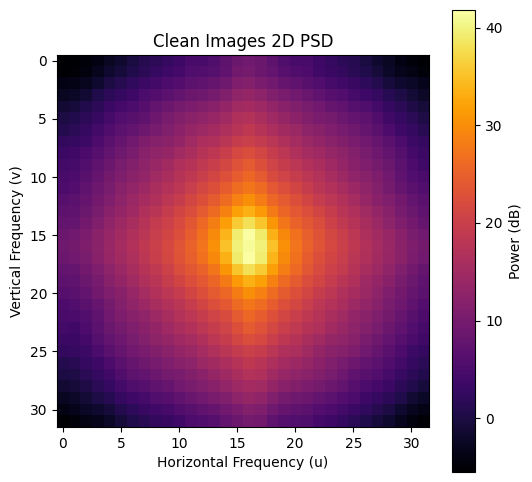

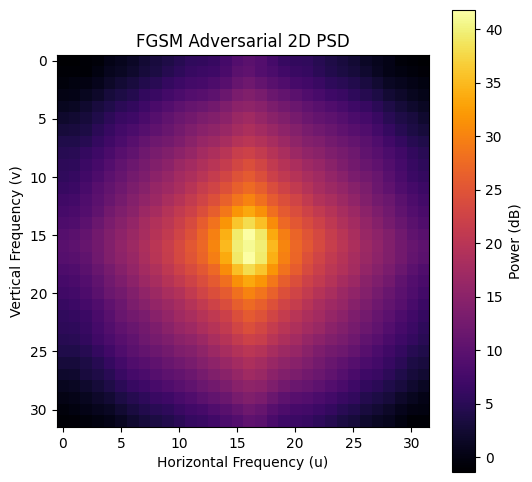

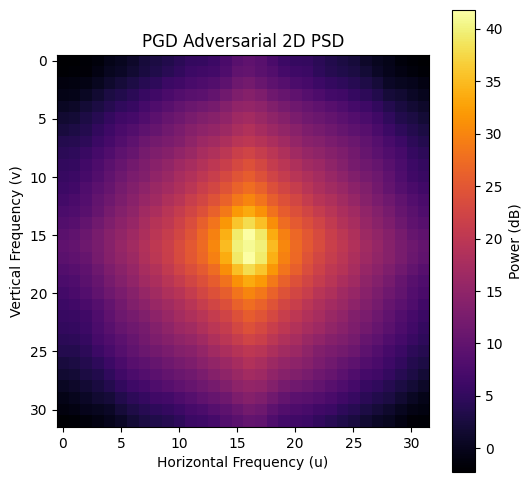

In [9]:
# Extract the underlying image tensors for plotting
clean_images, _ = clean_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(32, 32), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(clean_images, title="Clean Images 2D PSD")
analyzer.plot_2d(fgsm_images, title="FGSM Adversarial 2D PSD")
analyzer.plot_2d(pgd_images, title="PGD Adversarial 2D PSD")

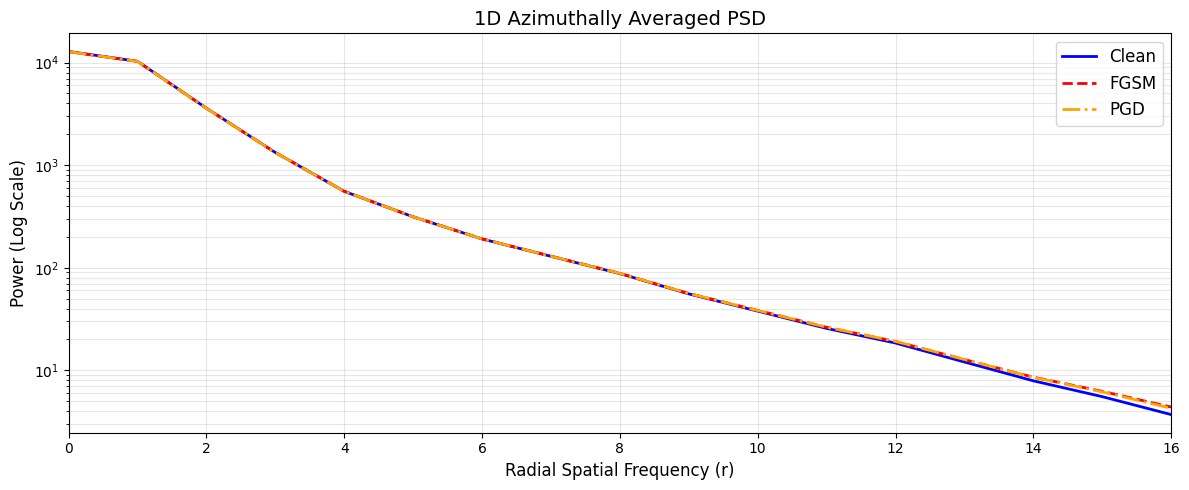

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:176: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=100)


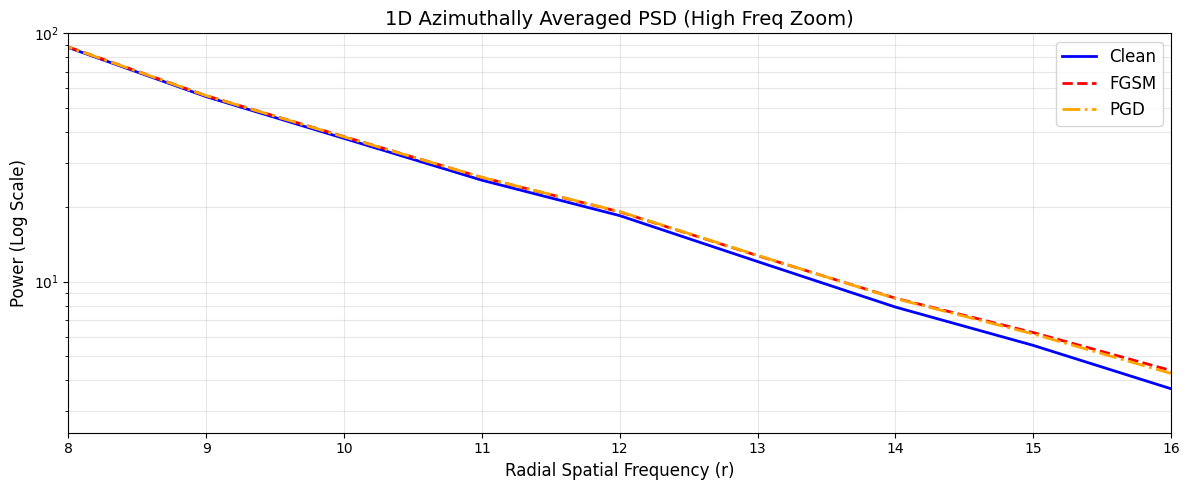

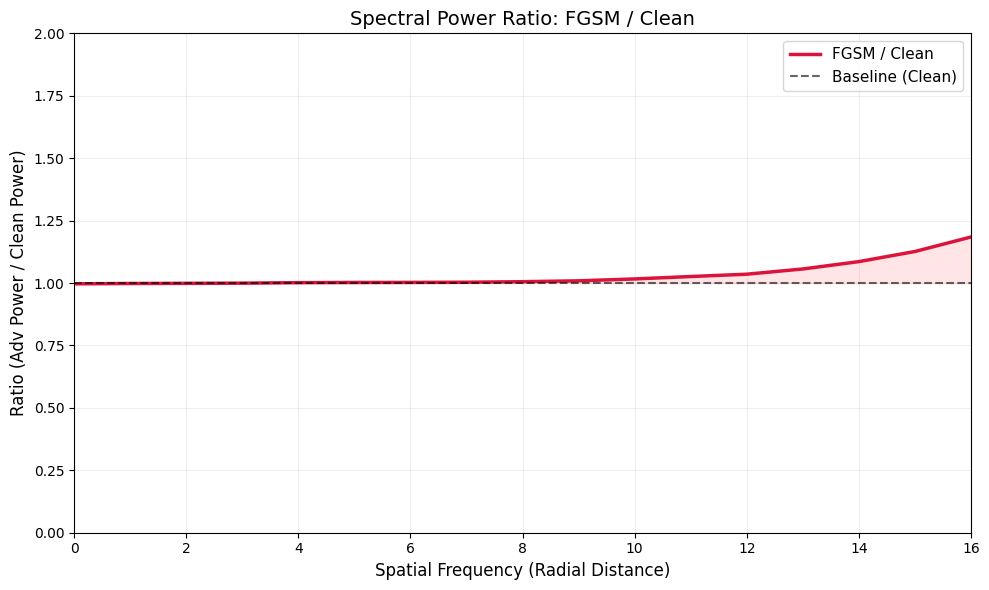

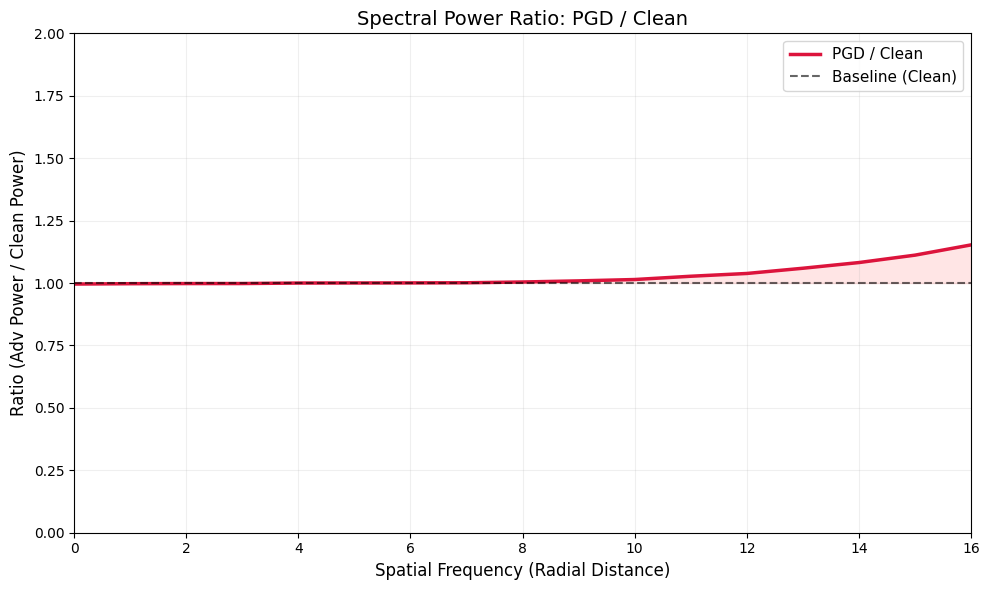

In [10]:
# Compare their 1D profiles on the same plot
analyzer.plot_1d({"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images})

# Compare their 1D profiles on the same plot
analyzer.plot_1d(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}, zoom_high_freq=True
)


analyzer.plot_1d_ratio(clean_images, fgsm_images, label="FGSM / Clean")
analyzer.plot_1d_ratio(clean_images, pgd_images, label="PGD / Clean")

Dataset    | Low-Freq Power (dB)  | High-Freq Power (dB)
-------------------------------------------------------
Clean      | 30.5400              | 12.4744             
FGSM       | 30.5412              | 12.7237             
PGD        | 30.5349              | 12.7039             


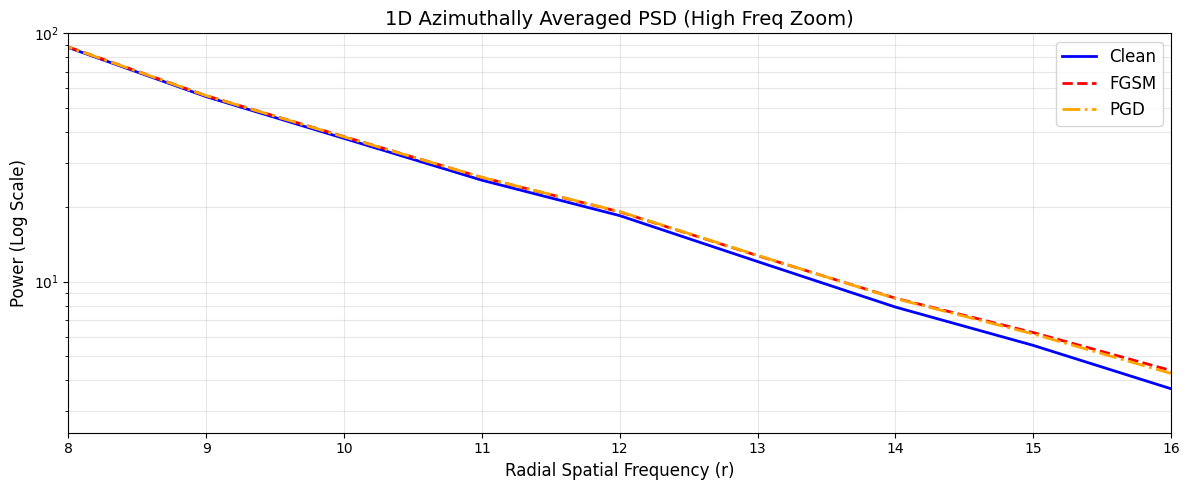

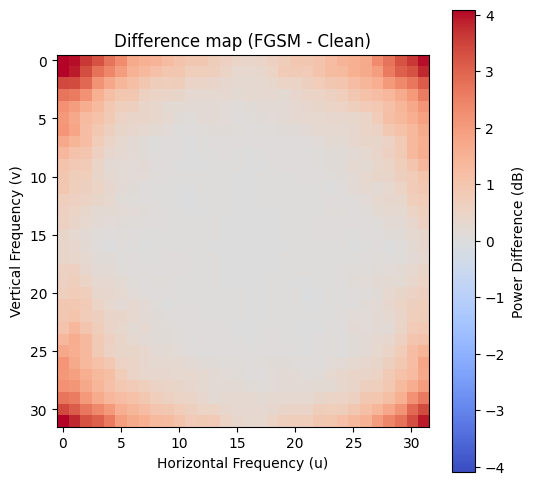

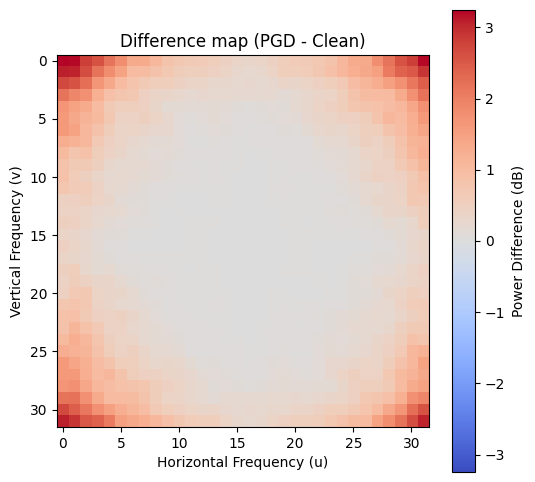

In [11]:
analyzer.print_spectral_stats(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}
)

analyzer.plot_1d(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}, zoom_high_freq=True
)

analyzer.plot_2d_difference(
    images_base=clean_images,
    images_adv=fgsm_images,
    title="Difference map (FGSM - Clean)",
)
analyzer.plot_2d_difference(
    images_base=clean_images,
    images_adv=pgd_images,
    title="Difference map (PGD - Clean)",
)